In [1]:
from model import EEGNet,MODMAset,EEG_SNN,SEEDEEGDataset
import torch
from torch.utils.data import DataLoader
import pytorch_grad_cam
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import os
import mne
import numpy as np

In [2]:
model = EEGNet(nb_classes=2,Channels=19, Samples=2000)
model.load_state_dict(torch.load('/home/ljy/work/LargeModel/spikemind/checkpoints/EEGNet.pth'))
# model = EEG_SNN(chans=19,num_nodes=128)
# model.load_state_dict(torch.load('/home/ljy/work/LargeModel/spikemind/checkpoints/EEGSNN.pth'))
model = model.eval()

In [3]:
train_path = '/home/data/data/NeuroLM_data/dataset/MODMA/train/'
train_ds = MODMAset(train_path,os.listdir(train_path))
# train_ds = SEEDEEGDataset()
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)

In [4]:
for i,(x, y) in enumerate(train_loader):
    eeg,label = x,y
    if i>5:
        break
print(label)

tensor([0])


([<matplotlib.axis.YTick at 0x7fe90d389e80>,
 [Text(0, 0, 'Fp1'), Text(0, 1, 'Fp2')])

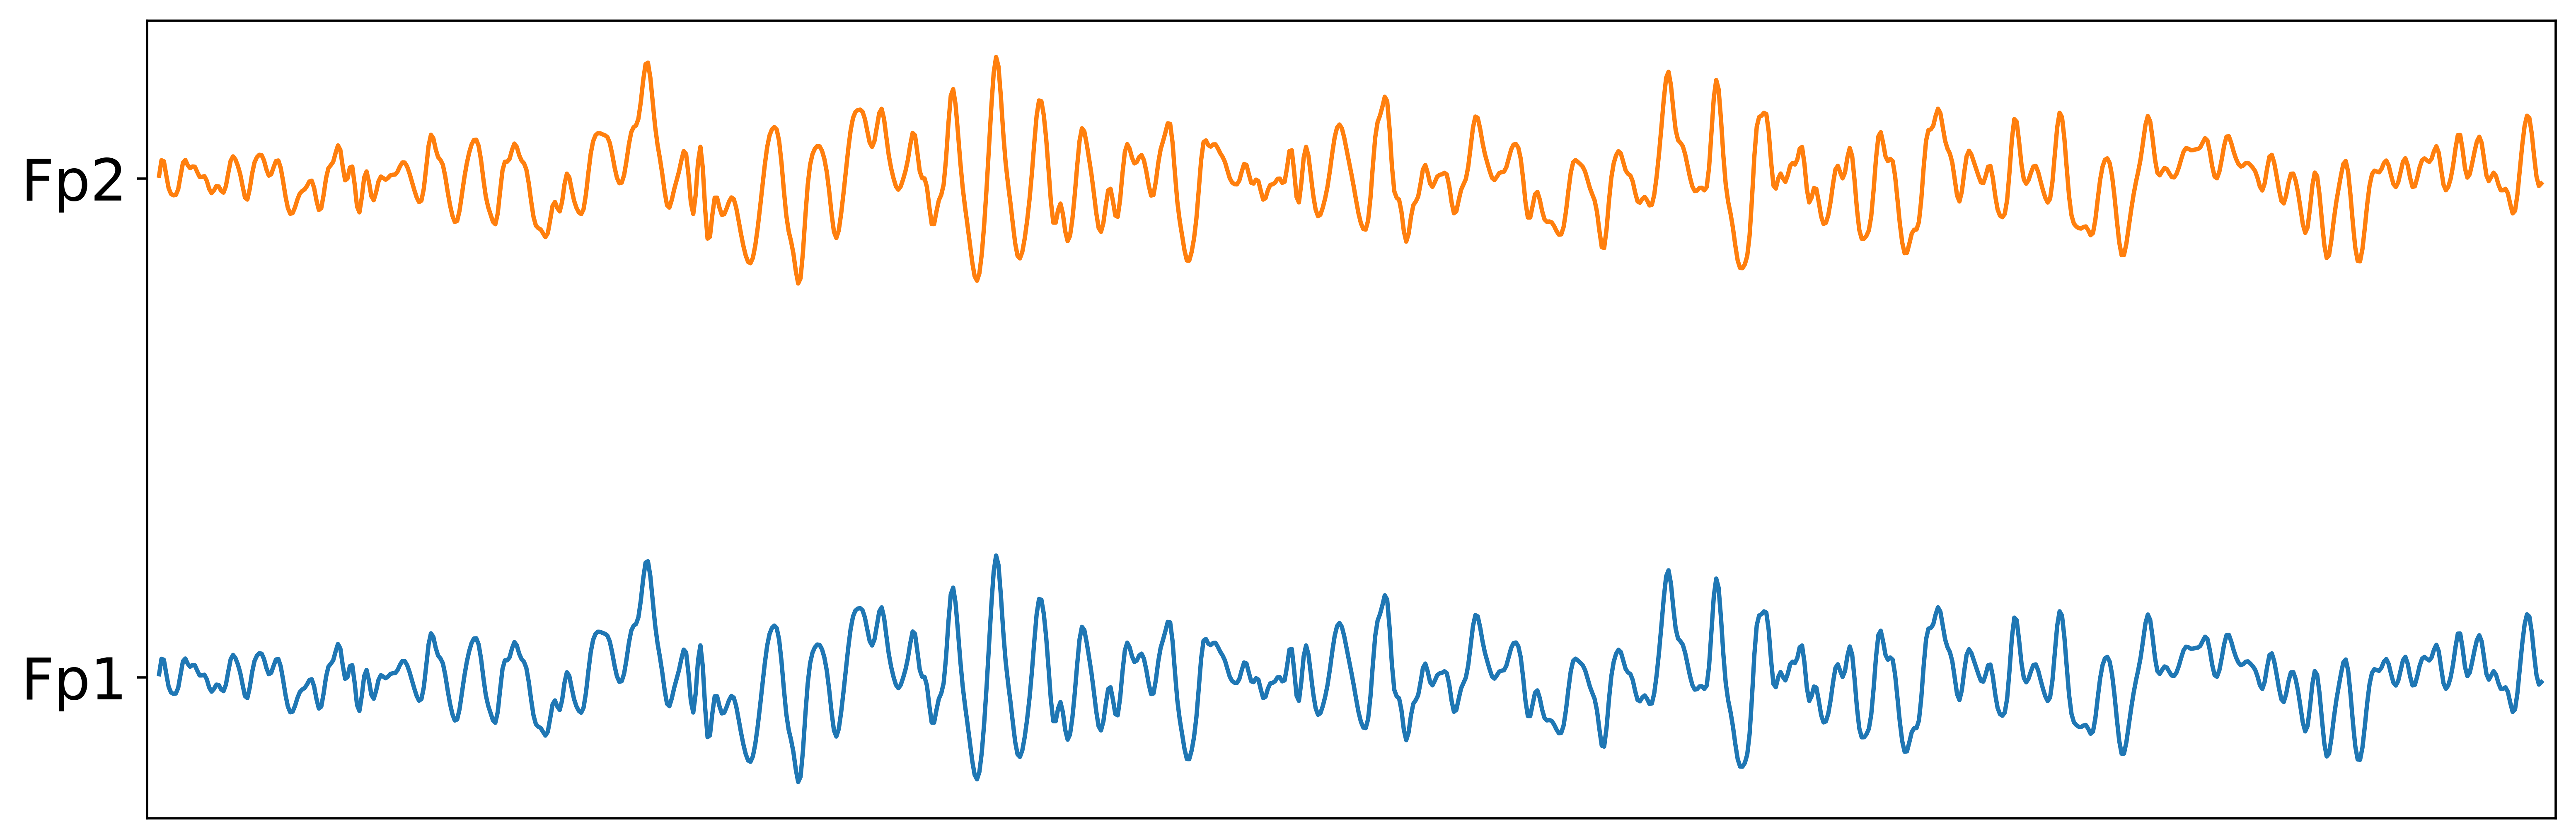

In [23]:
plt.rcParams['figure.dpi'] = 500
plt.rcParams['figure.figsize'] = (15,5)
from scipy.signal import welch, butter, filtfilt
import scipy
FS = 200
BP_LO = 1.0
BP_HI = 75.0
BP_ORDER = 5
nyq = FS / 2.0
b_diff, a_diff = butter(
    BP_ORDER,
    [BP_LO / nyq, BP_HI / nyq],
    btype='band'
)
b_notch, a_notch = scipy.signal.iirnotch(50, 35, FS)
eeg = scipy.signal.filtfilt(b_notch, a_notch, eeg)
eeg = filtfilt(b_diff, a_diff, eeg)
plt.plot(eeg[0,8,:1000])
plt.plot(eeg[0,8,:1000]+1)
plt.xlim(-5,1005)
plt.xticks([],[])
plt.yticks([0,1],['Fp1','Fp2'],size=20)

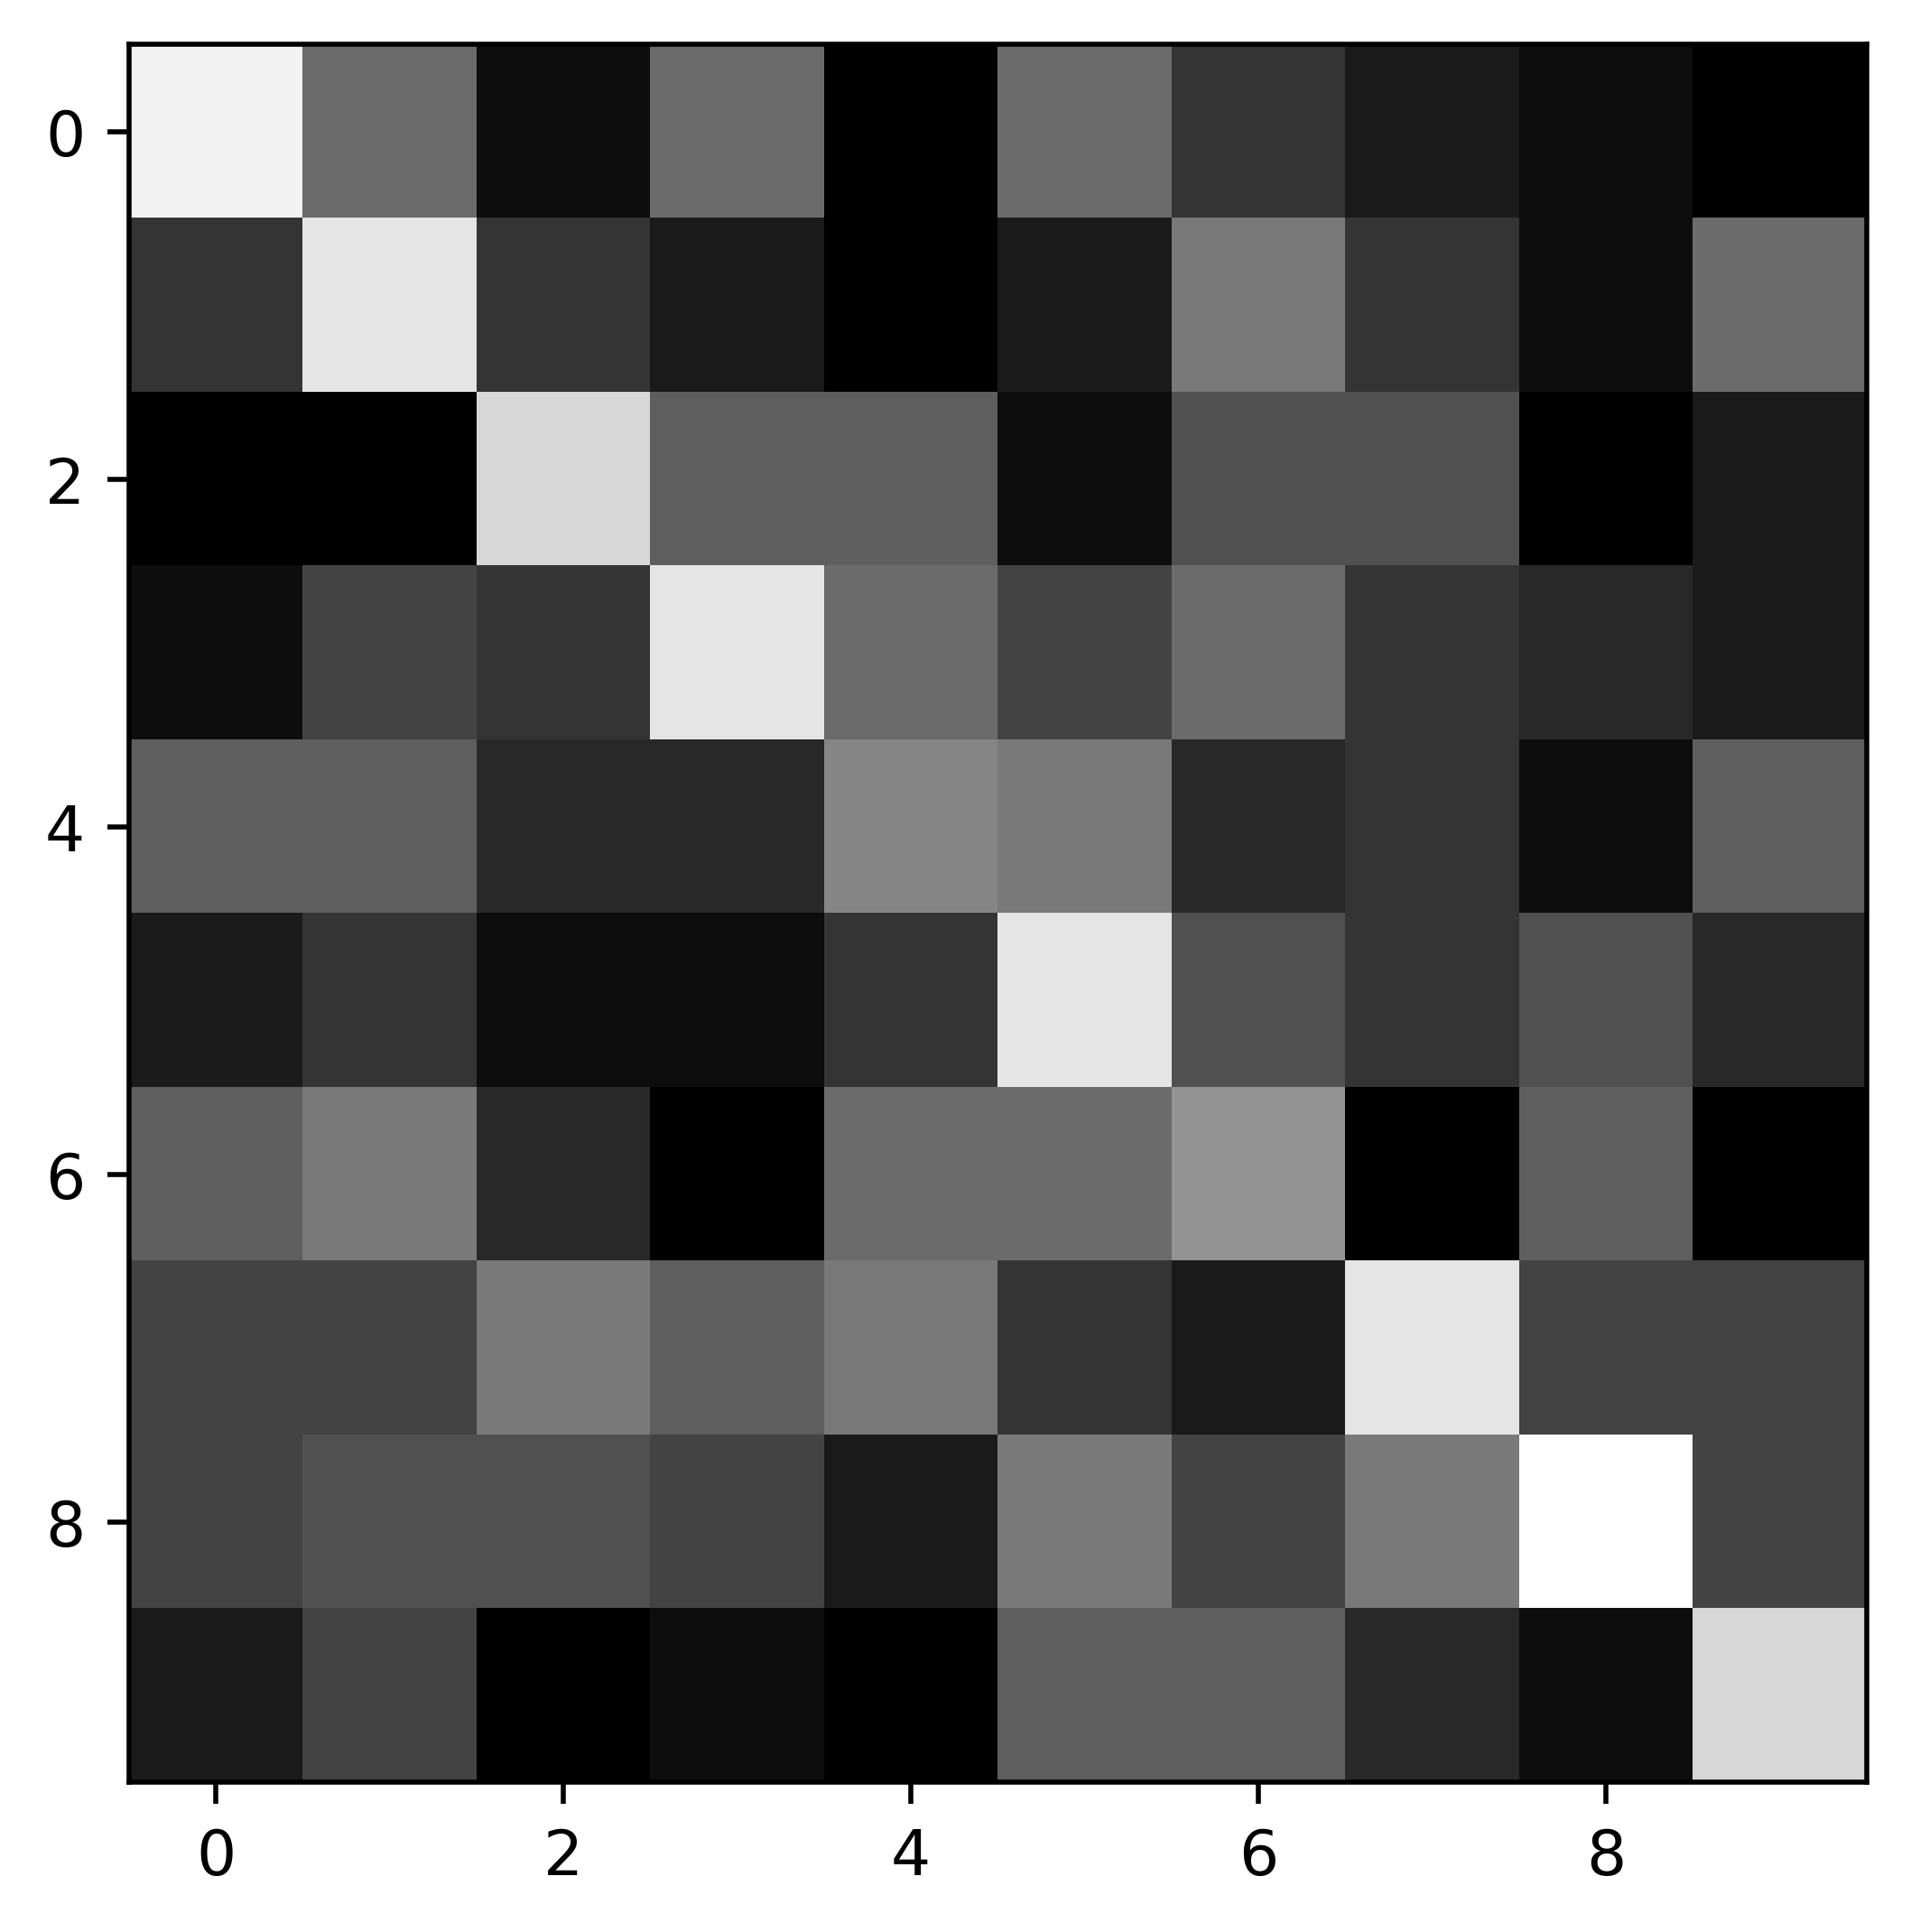

In [29]:
x = np.random.randint(0,10,(10,10))+np.eye(10)*10
plt.imshow(x,cmap='grey')

In [14]:
eeg.requires_grad_(True)
y,map = model(eeg)
map.retain_grad()
# y = torch.exp(y)/torch.exp(y).sum()
y = y*torch.tensor([[0,1.0]])
loss = y.sum()
loss.backward()
grad = eeg.grad[0]
grad = torch.relu(grad)
# grad = grad.sum(0)
grad = grad/grad.mean()
grad = grad.numpy()
# grad = np.delete(grad,57,axis=0)
# grad = np.delete(grad,60,axis=0)

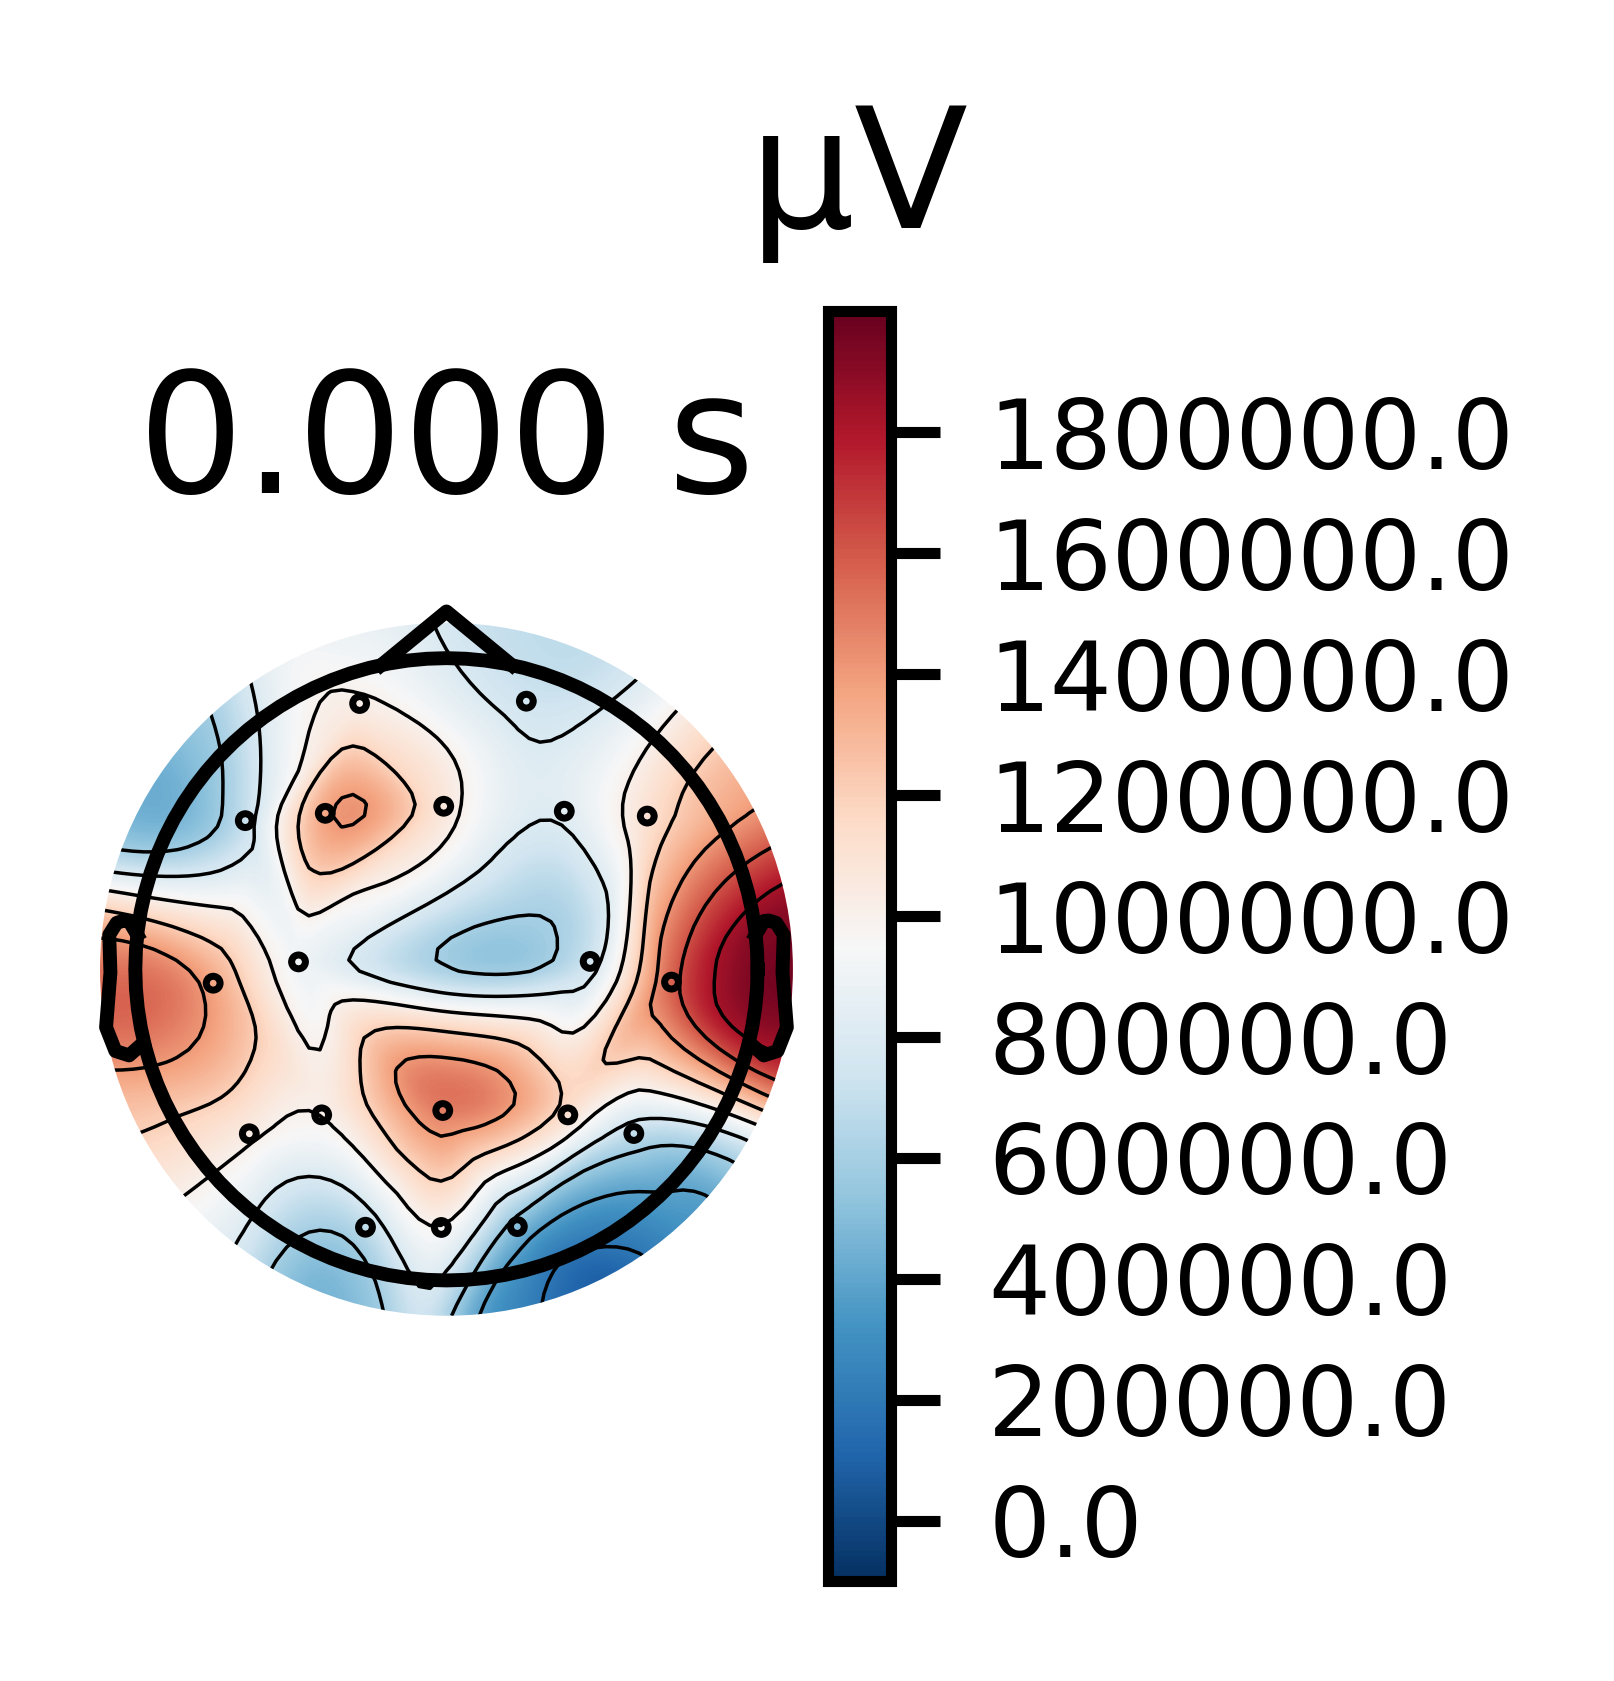

In [15]:
channels = ['FP1', 'FP2', 'F7', 'F3', 'F4', 'F8', 'C3', 'C4', 'T3', 'T4', 'P3', 'P4', 'PZ', 'FZ', 'T5', 'T6', 'O1', 'OZ', 'O2']
SEED_channels = ['FP1','FPZ','FP2','AF3','AF4','F7','F5','F3','F1','FZ','F2','F4','F6','F8','FT7','FC5','FC3','FC1','FCZ','FC2','FC4','FC6','FT8','T7','C5','C3','C1','CZ','C2','C4','C6','T8','TP7','CP5','CP3','CP1','CPZ','CP2','CP4','CP6','TP8','P7','P5','P3','P1','PZ','P2','P4','P6','P8','PO7','PO5','PO3','POZ','PO4','PO6','PO8','O1','OZ','O2']
sfreq = 200
info = mne.create_info(ch_names=channels, sfreq=sfreq, ch_types='eeg')
evoked = mne.EvokedArray(grad, info)
montage = mne.channels.make_standard_montage('standard_1020')
evoked.set_montage(montage, match_case=False)
average_data = np.mean(evoked.data, axis=1)  # 形状变为 (19,)

# 创建一个新的 Evoked 对象，只包含这个平均后的单点
evoked_average = mne.EvokedArray(average_data.reshape(-1, 1), evoked.info)
# evoked_average.times = np.array([0.0])  # 设置时间点为0
plt.rcParams['figure.dpi'] = 1000
# 绘制这个平均地形图
fig = evoked_average.plot_topomap(times=0,ch_type='eeg',contours=10,sphere=(0.00, 0.02, 0.00, 0.095),vlim=(-100000,2000000))
fig.savefig('./topo.png')

In [63]:
average_data.reshape(-1, 1).min()

np.float64(0.30551564796385355)

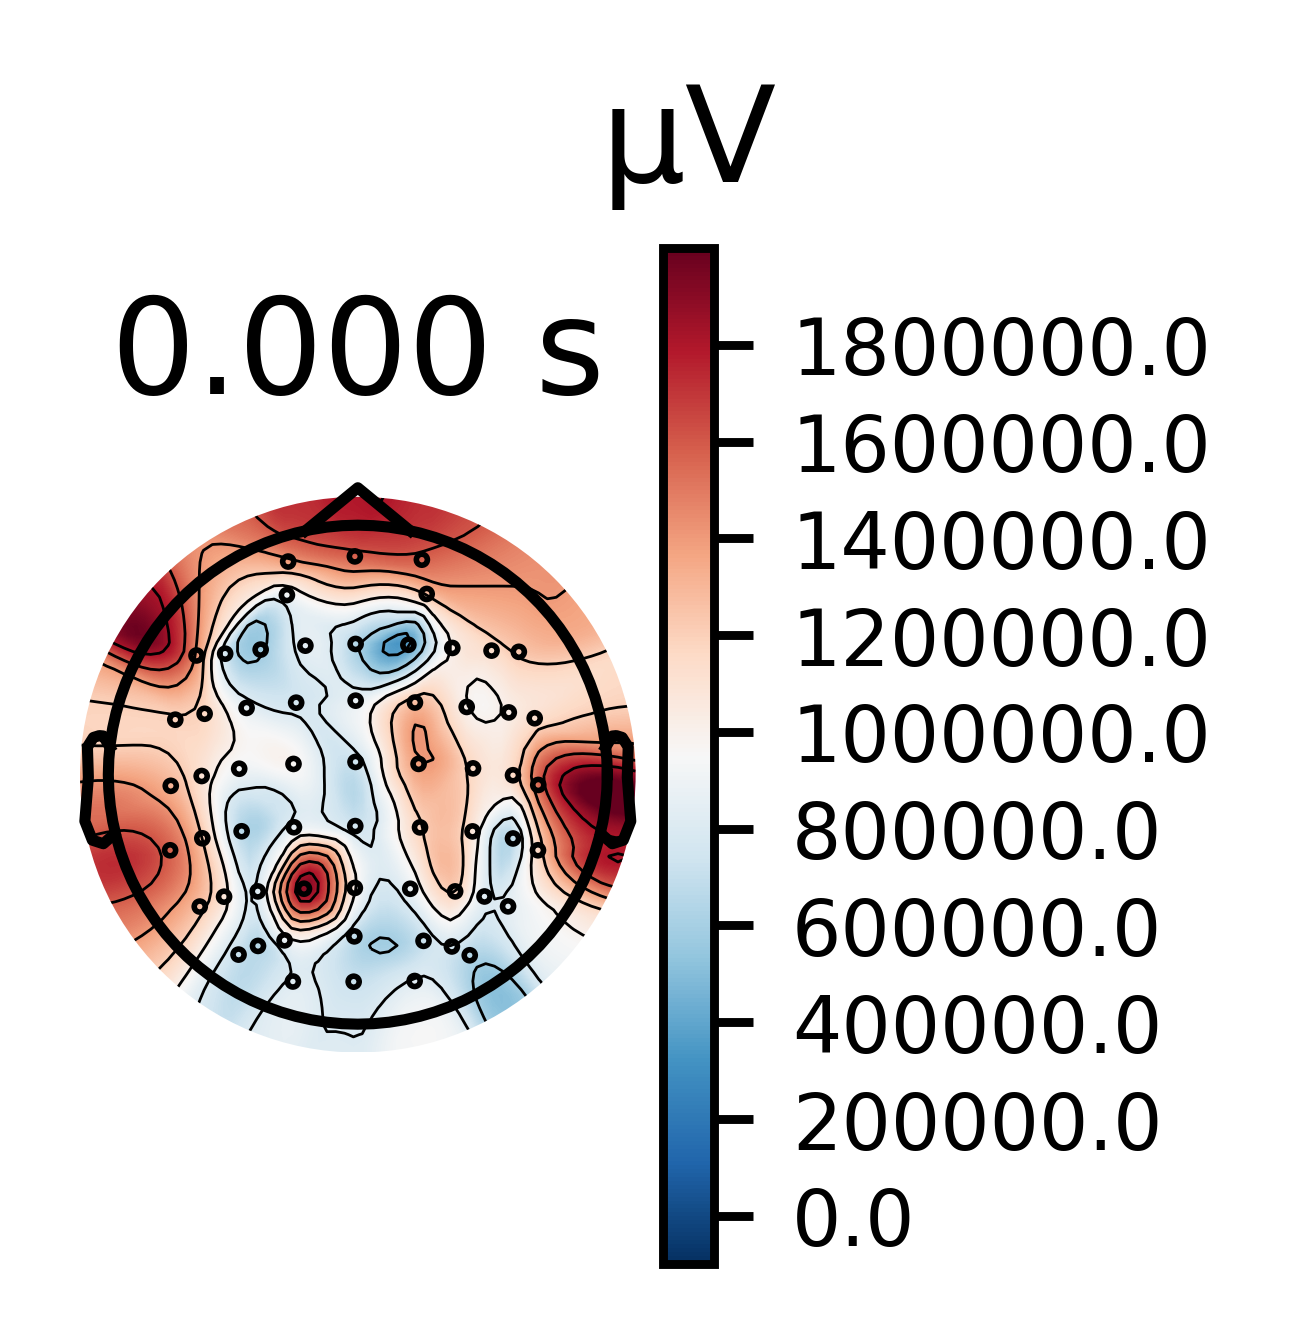

In [78]:
fig.set_dpi(800)
fig

In [7]:
with pytorch_grad_cam.GradCAM(model=model, target_layers=[model.fc]) as cam:
    grayscale_cam = cam(input_tensor=eeg, targets=[ClassifierOutputTarget(label)])

/home/ljy/miniconda3/envs/NeuroLM/lib/python3.12/site-packages/torch/nn/modules/conv.py:543: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv2d(


ValueError: Invalid grads shape.Shape of grads should be 4 (2D image) or 5 (3D image).

In [ ]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [15]:
model = resnet50()

In [18]:
[model.layer4[-1]]

[Bottleneck(
   (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
   (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
   (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
 )]